# Calibration

**This notebook assesses calibration performance of the gradient boosted survival model and recalibrates predictions using isotonic regression for patients with advanced head and neck cancer receiving first-line pembrolizumab plus chemotherapy or pembrolizumab.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_df = pd.read_csv('../outputs/gb_survival_predictions.csv')

In [3]:
survival_predictions_df = survival_predictions_df[['PatientID', 'risk_score', 'psurv_180', 'psurv_365']]

In [4]:
survival_predictions_df.shape

(8718, 4)

In [5]:
dtype_map = pd.read_csv('../outputs/pembrochemo_pembro_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_pembrochemo_df = pd.read_csv('../outputs/pembrochemo_pembro_features_df.csv', dtype = dtype_map)

In [6]:
pembro_pembrochemo_df.shape

(1736, 162)

In [7]:
df = pd.merge(pembro_pembrochemo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [8]:
df.shape

(1736, 165)

In [9]:
df = df.query('adv_diagnosis_year <= 2021')

In [10]:
df.shape

(1257, 165)

## Raw Calibration Assessment

In [11]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [12]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.011699999999999999, 0.517]",0.372790,0.304196,126,0.216823,0.385645
1,"(0.517, 0.65]",0.593901,0.515477,126,0.420507,0.599429
2,"(0.65, 0.708]",0.678567,0.649927,125,0.555855,0.728934
3,"(0.708, 0.751]",0.732555,0.627695,126,0.530100,0.700972
4,"(0.751, 0.783]",0.768540,0.740548,126,0.644561,0.801574
5,"(0.783, 0.812]",0.798948,0.819028,125,0.738209,0.876950
6,"(0.812, 0.836]",0.824332,0.832354,126,0.747268,0.884925
7,"(0.836, 0.861]",0.848422,0.893725,125,0.822202,0.935704
8,"(0.861, 0.886]",0.873680,0.925170,126,0.859713,0.959581
9,"(0.886, 0.938]",0.904569,0.950463,126,0.893048,0.977439


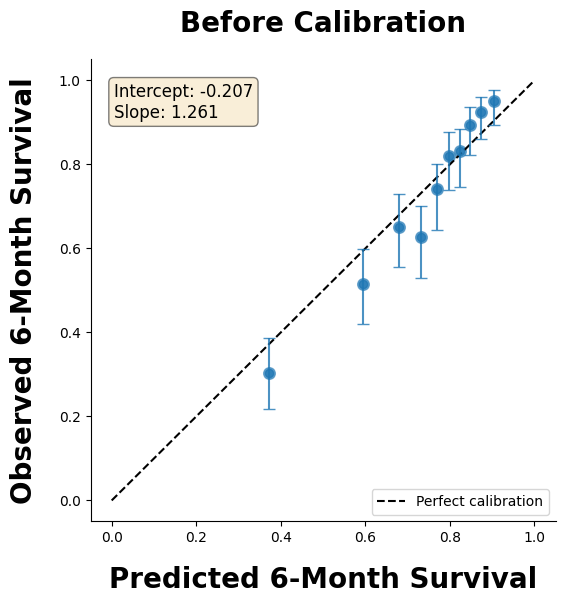

In [13]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/uncalibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()

## Isotonic Calibration Using Cross Validation 

In [14]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [15]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1813

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1592

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1726

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1489

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1526

=== Summary ===
psurv_180_calibrated computed: 1257

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1629 ± 0.0122


In [16]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [17]:
df_final_calibrated.to_csv('../outputs/gb_6m_survival_predictions_calibrated.csv', index = False)

In [18]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [19]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.478]",0.322928,0.361248,135,0.272163,0.441774
1,"(0.478, 0.6]",0.541198,0.522872,130,0.429304,0.605345
2,"(0.6, 0.639]",0.625325,0.664438,121,0.569179,0.743373
3,"(0.639, 0.675]",0.658099,0.593160,120,0.498719,0.675638
4,"(0.675, 0.757]",0.736625,0.752298,140,0.659082,0.806306
5,"(0.757, 0.833]",0.803686,0.822357,112,0.735569,0.882891
6,"(0.833, 0.885]",0.856319,0.862195,143,0.790725,0.908604
7,"(0.885, 0.915]",0.897060,0.886036,107,0.805506,0.931992
8,"(0.915, 0.933]",0.927611,0.892927,130,0.822100,0.936054
9,"(0.933, 1.0]",0.977827,0.948556,119,0.889066,0.976557


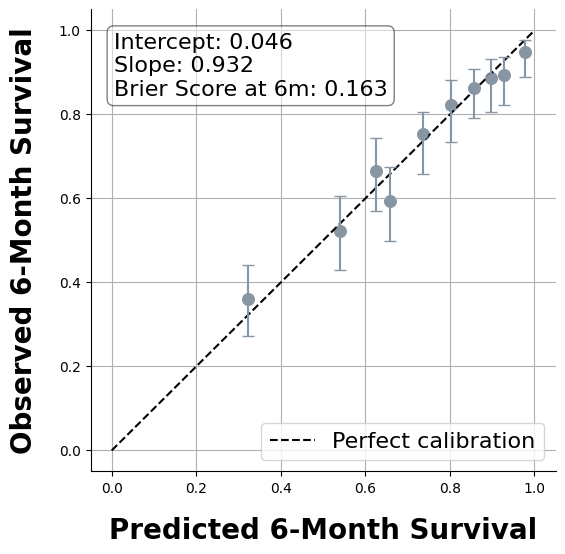

In [20]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color = '#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Regression',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.savefig('../outputs/calibrated_gb_6m_survival_prediction_plot.pdf', format = 'pdf', bbox_inches = 'tight')

plt.show()